In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
def count_parameters(model):
    return sum(x.flatten().shape[0] for x in model.parameters() if hasattr(x, "shape"))


def render_graph(tensor, params=None):
    from torchviz import make_dot

    # Visualize the graph
    dot = make_dot(tensor, params=params)
    # Render the graph to a file (requires Graphviz installed on your system)
    dot.render("computational_graph", format="png")
    # Display in Jupyter Notebook (if using one)
    return dot

## Create Datasets


In [3]:
SAMPLE_SIZE = 500
NOISE_FACTOR = 0.05
RANDOM_SEED = 1990
torch.manual_seed(RANDOM_SEED)

In [4]:
x = torch.linspace(-10, 10, SAMPLE_SIZE).unsqueeze(1)
noise = torch.randn(SAMPLE_SIZE).unsqueeze(1) * NOISE_FACTOR

In [5]:
def count_parameters(model):
    return sum(x.flatten().shape[0] for x in model.parameters() if hasattr(x, "shape"))

In [6]:
def function_linear(x, noise):
    return 0.123 * x + 0.234 + noise


def function_poly(x, noise):
    return 0.01 * x**2 + 0.05 * x + 1 + noise


def function_trig(x, noise):
    return torch.sin(x) + 0.5 * torch.cos(2 * x) + noise


def function_cmplx(x, noise):
    return torch.sin(torch.sqrt(x) ** 3) * torch.cos(x) - 0.05 * x ** (3 / 2) + noise

In [7]:
data_linear = x, function_linear(x, noise)
data_poly = x, function_poly(x, noise)
data_trig = x, function_trig(x, noise)
data_cmplx = x, function_cmplx(x, noise)

Text(0.5, 1.0, 'Data Samples')

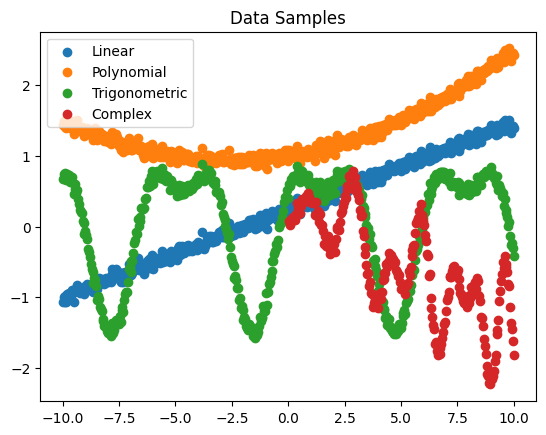

In [8]:
plt.scatter(*data_linear, label="Linear")
plt.scatter(*data_poly, label="Polynomial")
plt.scatter(*data_trig, label="Trigonometric")
plt.scatter(*data_cmplx, label="Complex")
plt.legend(loc="upper left")
plt.title("Data Samples")

## Model for the Linear Dataset


In [9]:
class ModelLinear(nn.Module):
    def __init__(self, input_dim, output_dim=1):
        super(ModelLinear, self).__init__()
        self.fc1 = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        return x

In [10]:
X, y = data_linear

N_FEATURES = X.shape[1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=RANDOM_SEED, shuffle=True
)

x_scaler = StandardScaler()
x_train_scaled = torch.tensor(x_scaler.fit_transform(X_train), dtype=torch.float32)
x_test_scaled = torch.tensor(x_scaler.transform(X_test), dtype=torch.float32)

y_scaler = StandardScaler()
y_train_scaled = torch.tensor(
    y_scaler.fit_transform(y_train.reshape(-1, 1)), dtype=torch.float32
)
y_test_scaled = torch.tensor(
    y_scaler.transform(y_test.reshape(-1, 1)), dtype=torch.float32
)

[
    (x.shape, type(x))
    for x in (
        X_train,
        X_test,
        y_train,
        y_test,
        x_train_scaled,
        x_test_scaled,
        y_train_scaled,
        y_test_scaled,
    )
]

[(torch.Size([335, 1]), torch.Tensor),
 (torch.Size([165, 1]), torch.Tensor),
 (torch.Size([335, 1]), torch.Tensor),
 (torch.Size([165, 1]), torch.Tensor),
 (torch.Size([335, 1]), torch.Tensor),
 (torch.Size([165, 1]), torch.Tensor),
 (torch.Size([335, 1]), torch.Tensor),
 (torch.Size([165, 1]), torch.Tensor)]

In [11]:
print("x,y shapes:", x_train_scaled.shape, y_train_scaled.shape)
fc1 = nn.Linear(1, 1)
print(f"{fc1.weight.data.shape=}")
print()
print(
    f"nn.Linear calculation : {x_train_scaled.shape=} @ {fc1.weight.data.T.shape=} + {fc1.bias.data.shape=}"
)
print()
res1 = torch.matmul(x_train_scaled, fc1.weight.data.T) + fc1.bias.data
res2 = fc1(x_train_scaled)
print(res1.shape, res2.shape)
all(res1 == res2)

x,y shapes: torch.Size([335, 1]) torch.Size([335, 1])
fc1.weight.data.shape=torch.Size([1, 1])

nn.Linear calculation : x_train_scaled.shape=torch.Size([335, 1]) @ fc1.weight.data.T.shape=torch.Size([1, 1]) + fc1.bias.data.shape=torch.Size([1])

torch.Size([335, 1]) torch.Size([335, 1])


True

In [12]:
model_linear = ModelLinear(input_dim=N_FEATURES, output_dim=1)

In [13]:
LEARNING_RATE = 0.01
EPOCHS = 500

In [14]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model_linear.parameters(), lr=LEARNING_RATE)
count_parameters(model_linear)

2

## Understanding the Training Loop Components

- `y = model(X)` : Calculate forward pass
- `loss = criterion(y_pred, y)` : Calculate loss
- `optimizer.zero_grad()`: Clear the `.grad` attribute of all parameters tracked by the optimizer
- `loss.backward()`: Calculate gradients for ALL DAG tensors with `requires_grad=True`. After that graph is freed unless `retain_graph=True`
- `optimizer.step()` : Updates parameters that are registered with the optimizer


## Performing Training Steps Once Manually


In [15]:
y_pred = model_linear(x_train_scaled)
loss = criterion(y_pred, y_train_scaled)
optimizer.zero_grad()
loss.backward()

In [16]:
# before backpropagation update
print(f"{model_linear.fc1.weight.data=}, {model_linear.fc1.bias.data=}")
print(f"{model_linear.fc1.weight.grad=}, {model_linear.fc1.bias.grad=}")

model_linear.fc1.weight.data=tensor([[-0.7058]]), model_linear.fc1.bias.data=tensor([-0.8452])
model_linear.fc1.weight.grad=tensor([[-3.4062]]), model_linear.fc1.bias.grad=tensor([-1.6904])


In [17]:
# This calculation is assumes SGD - different optimizers follow different update schemes
print(
    f"new weights : {model_linear.fc1.weight.data - model_linear.fc1.weight.grad * LEARNING_RATE}"
)
print(
    f"new bias : {model_linear.fc1.bias.data - model_linear.fc1.bias.grad * LEARNING_RATE}"
)

new weights : tensor([[-0.6717]])
new bias : tensor([-0.8283])


In [18]:
optimizer.step()
# after backpropagation update
print(f"{model_linear.fc1.weight.data=}, {model_linear.fc1.bias.data=}")
print(f"{model_linear.fc1.weight.grad=}, {model_linear.fc1.bias.grad=}")

model_linear.fc1.weight.data=tensor([[-0.6958]]), model_linear.fc1.bias.data=tensor([-0.8352])
model_linear.fc1.weight.grad=tensor([[-3.4062]]), model_linear.fc1.bias.grad=tensor([-1.6904])


In [19]:
optimizer.zero_grad()
print(f"{model_linear.fc1.weight.grad=}, {model_linear.fc1.bias.grad=}")

model_linear.fc1.weight.grad=None, model_linear.fc1.bias.grad=None


## Training using the EPOCHS Loop


In [20]:
# L = []
# model_linear.train()  # set the model to training mode

# for epoch in range(EPOCHS):
#     y_pred = model_linear(x_train_scaled)
#     # loss
#     loss = criterion(y_pred, y_train_scaled)
#     # zero gradient
#     optimizer.zero_grad()
#     # backward
#     loss.backward()
#     # update weights
#     optimizer.step()
#     # log metrics
#     L.append(loss.item())
#     # print epoch statistics
#     if epoch % 50 == 0:
#         print(f"{epoch=} loss : {loss:.2f}")

## Training + Evaluation EPOCHS Loop


In [21]:
L_train = []
L_test = []

for epoch in range(EPOCHS):
    # set the model to training mode
    model_linear.train()
    # forward pass
    y_pred = model_linear(x_train_scaled)
    # compute loss
    train_loss = criterion(y_pred, y_train_scaled)
    # zero gradient, backward, update weights
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()
    # log metrics
    L_train.append(train_loss.item())

    # set the model to evaluation mode
    model_linear.eval()
    with torch.no_grad():
        y_test_pred = model_linear(x_test_scaled)
        test_loss = criterion(y_test_pred, y_test_scaled)
        L_test.append(test_loss.item())

    # print epoch statistics
    if epoch % 50 == 0:
        print(f"{epoch=}/{EPOCHS}: {train_loss=:.4f}, {test_loss=:.4f}")

epoch=0/500: train_loss=3.5695, test_loss=4.0142
epoch=50/500: train_loss=1.6259, test_loss=1.8029
epoch=100/500: train_loss=0.6827, test_loss=0.7419
epoch=150/500: train_loss=0.2650, test_loss=0.2843
epoch=200/500: train_loss=0.0919, test_loss=0.0989
epoch=250/500: train_loss=0.0298, test_loss=0.0328
epoch=300/500: train_loss=0.0112, test_loss=0.0127
epoch=350/500: train_loss=0.0065, test_loss=0.0075
epoch=400/500: train_loss=0.0056, test_loss=0.0063
epoch=450/500: train_loss=0.0054, test_loss=0.0061


In [22]:
# print(
#     f"Estimated parameters for linear model are (this is relevant if there is no scaling during preprocessing): {model_linear.fc1.weight.data.item():.3f}, {model_linear.fc1.bias.data.item():.3f}"
# )

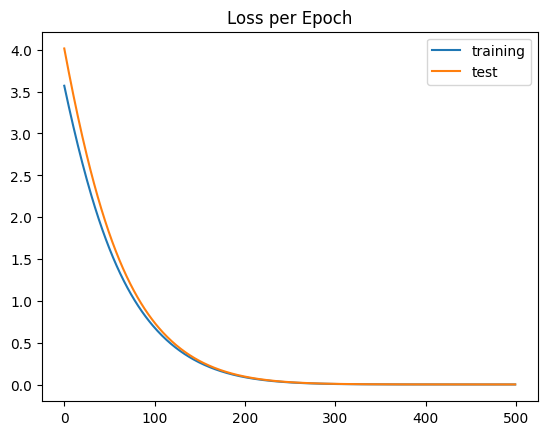

In [23]:
x_axis_values = list(range(EPOCHS))
plt.plot(x_axis_values, L_train, label="training")
plt.plot(x_axis_values, L_test, label="test")
plt.title("Loss per Epoch")
plt.legend()

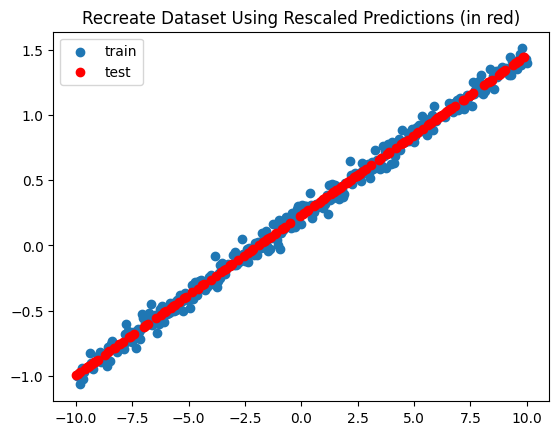

In [24]:
y_test_pred_rescaled = y_scaler.inverse_transform(y_test_pred.reshape(-1, 1))

plt.scatter(X_train, y_train, label="train")
plt.scatter(
    X_test,
    y_test_pred_rescaled,
    color="red",
    label="test",
)
plt.title("Recreate Dataset Using Rescaled Predictions (in red)")
plt.legend()

In [25]:
# Train ----------------------------------
y_pred_train_scaled = model_linear(x_train_scaled).detach().numpy()
y_train_scaled_numpy = y_train_scaled.detach().numpy()
print(f"train error : {np.mean(y_train_scaled_numpy - y_pred_train_scaled).item():.4f}")

# Test ----------------------------------
y_pred_test_scaled = model_linear(x_test_scaled).detach().numpy()
y_test_scaled_numpy = y_test_scaled.detach().numpy()
print(f"test error : {np.mean(y_test_scaled_numpy - y_pred_test_scaled).item():.4f}")

train error : 0.0000
test error : 0.0023


Text(0.5, 1.0, 'Actual vs Predicted Scaled (Test)')

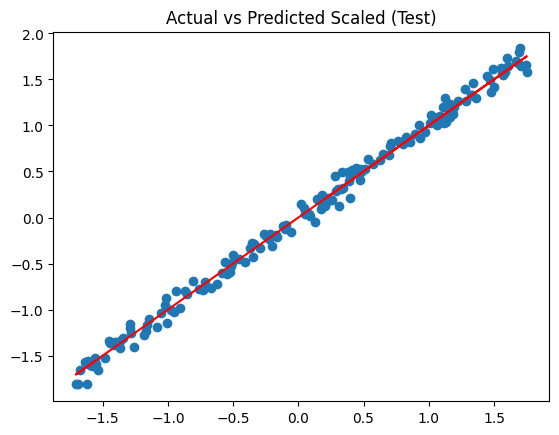

In [26]:
plt.scatter(y_pred_test_scaled, y_test_scaled_numpy)
plt.plot(y_pred_test_scaled, y_pred_test_scaled, "r-")
plt.title("Actual vs Predicted Scaled (Test)")

Text(0.5, 1.0, "Errors Diagnostics (Test) - 'Must be Random'")

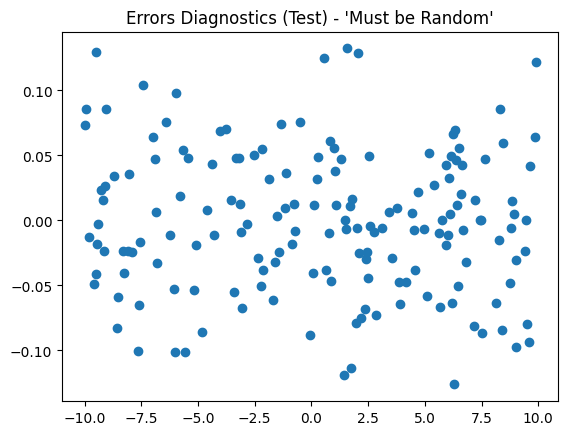

In [27]:
errors = y_test_pred_rescaled - y_test.detach().numpy()
plt.scatter(X_test, errors)
plt.title("Errors Diagnostics (Test) - 'Must be Random'")

## Model for the Polynomial Dataset


In [28]:
class ModelPoly(nn.Module):
    def __init__(self, input_dim, hidden_units, output_dim=1):
        super(ModelPoly, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_units)
        self.fc2 = nn.Linear(hidden_units, output_dim)
        self.activation = nn.Tanh()

    def forward(self, x):
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        return x

In [29]:
X, y = data_poly

N_FEATURES = X.shape[1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=RANDOM_SEED, shuffle=True
)

x_scaler = StandardScaler()
x_train_scaled = torch.tensor(x_scaler.fit_transform(X_train), dtype=torch.float32)
x_test_scaled = torch.tensor(x_scaler.transform(X_test), dtype=torch.float32)

y_scaler = StandardScaler()
y_train_scaled = torch.tensor(
    y_scaler.fit_transform(y_train.reshape(-1, 1)), dtype=torch.float32
)
y_test_scaled = torch.tensor(
    y_scaler.transform(y_test.reshape(-1, 1)), dtype=torch.float32
)

In [30]:
model_poly = ModelPoly(input_dim=N_FEATURES, hidden_units=64, output_dim=1)

In [31]:
LEARNING_RATE = 0.01
EPOCHS = 1000

In [32]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model_poly.parameters(), lr=LEARNING_RATE)
count_parameters(model_poly)

193

In [33]:
L_train = []
L_test = []

for epoch in range(EPOCHS):
    # set the model to training mode
    model_poly.train()
    # forward pass
    y_pred = model_poly(x_train_scaled)
    # compute loss
    train_loss = criterion(y_pred, y_train_scaled)
    # zero gradient, backward, update weights
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()
    # log metrics
    L_train.append(train_loss.item())

    # set the model to evaluation mode
    model_poly.eval()
    with torch.no_grad():
        y_test_pred = model_poly(x_test_scaled)
        test_loss = criterion(y_test_pred, y_test_scaled)
        L_test.append(test_loss.item())

    # print epoch statistics
    if epoch % 50 == 0:
        print(f"{epoch=}/{EPOCHS}: {train_loss=:.4f}, {test_loss=:.4f}")

epoch=0/1000: train_loss=1.0393, test_loss=0.7506
epoch=50/1000: train_loss=0.0352, test_loss=0.0385
epoch=100/1000: train_loss=0.0228, test_loss=0.0253
epoch=150/1000: train_loss=0.0193, test_loss=0.0212
epoch=200/1000: train_loss=0.0176, test_loss=0.0193
epoch=250/1000: train_loss=0.0167, test_loss=0.0182
epoch=300/1000: train_loss=0.0162, test_loss=0.0176
epoch=350/1000: train_loss=0.0159, test_loss=0.0173
epoch=400/1000: train_loss=0.0157, test_loss=0.0171
epoch=450/1000: train_loss=0.0156, test_loss=0.0169
epoch=500/1000: train_loss=0.0155, test_loss=0.0169
epoch=550/1000: train_loss=0.0155, test_loss=0.0168
epoch=600/1000: train_loss=0.0155, test_loss=0.0168
epoch=650/1000: train_loss=0.0154, test_loss=0.0168
epoch=700/1000: train_loss=0.0154, test_loss=0.0168
epoch=750/1000: train_loss=0.0154, test_loss=0.0168
epoch=800/1000: train_loss=0.0154, test_loss=0.0168
epoch=850/1000: train_loss=0.0154, test_loss=0.0168
epoch=900/1000: train_loss=0.0154, test_loss=0.0168
epoch=950/1000:

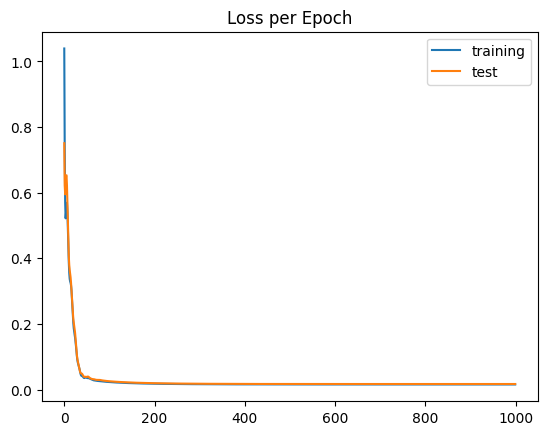

In [34]:
x_axis_values = list(range(EPOCHS))
plt.plot(x_axis_values, L_train, label="training")
plt.plot(x_axis_values, L_test, label="test")
plt.title("Loss per Epoch")
plt.legend()

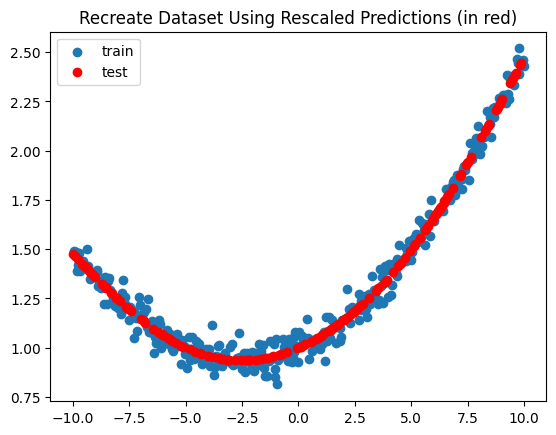

In [35]:
y_test_pred_rescaled = y_scaler.inverse_transform(y_test_pred.reshape(-1, 1))

plt.scatter(X_train, y_train, label="train")
plt.scatter(
    X_test,
    y_test_pred_rescaled,
    color="red",
    label="test",
)
plt.title("Recreate Dataset Using Rescaled Predictions (in red)")
plt.legend()

In [36]:
# Train ----------------------------------
y_pred_train_scaled = model_poly(x_train_scaled).detach().numpy()
y_train_scaled_numpy = y_train_scaled.detach().numpy()
print(f"train error : {np.mean(y_train_scaled_numpy - y_pred_train_scaled).item():.4f}")

# Test ----------------------------------
y_pred_test_scaled = model_poly(x_test_scaled).detach().numpy()
y_test_scaled_numpy = y_test_scaled.detach().numpy()
print(f"test error : {np.mean(y_test_scaled_numpy - y_pred_test_scaled).item():.4f}")

train error : 0.0000
test error : 0.0044


Text(0.5, 1.0, 'Actual vs Predicted Scaled (Test)')

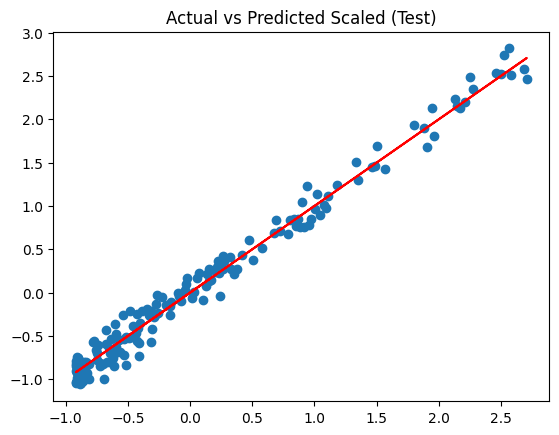

In [37]:
plt.scatter(y_pred_test_scaled, y_test_scaled_numpy)
plt.plot(y_pred_test_scaled, y_pred_test_scaled, "r-")
plt.title("Actual vs Predicted Scaled (Test)")

Text(0.5, 1.0, "Errors Diagnostics (Test) - 'Must be Random'")

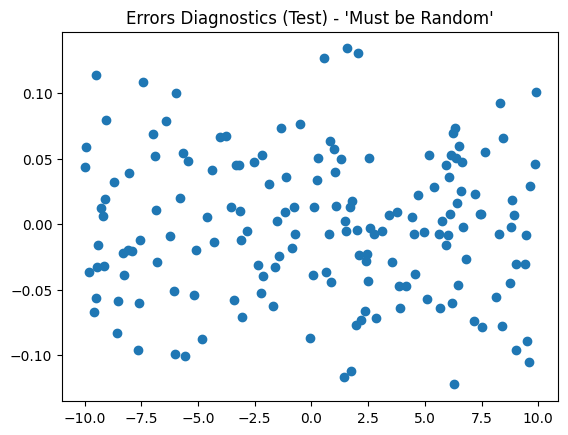

In [38]:
errors = y_test_pred_rescaled - y_test.detach().numpy()
plt.scatter(X_test, errors)
plt.title("Errors Diagnostics (Test) - 'Must be Random'")